ตรวจสภาพแวดล้อม

In [1]:
import sys
import platform

print(sys.executable)
print(platform.system())

/opt/conda/bin/python
Linux


### ตรวจ SITE ที่จะทำการ Prediction

In [2]:
import os
os.environ["UWIN_SITE"] = "GWD_10_160"

from uwinControl import config
SITE = config.get_site()
print(SITE["station_code"])

GWD_10_160


## uwin - Pipeline

### เรียกใช้ฟังก์ชันต่างๆ จากโฟลเดอร์ src

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from uwinControl import config, data_io, energy, features, finance, models, qc, simulate

# ตั้งค่ากราฟ
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# อ่านค่าไซต์งานจาก env UWIN_SITE
SITE = config.get_site() # อ่านจาก UWIN_SITE ใน docker-compose
print('ไซต์งาน  :', SITE['station_code'])
print('เสาวัดลม :', SITE['mast_height_m'], 'ม.')
print('จังหวัด  :', SITE['province'])

ไซต์งาน  : GWD_10_160
เสาวัดลม : 160  ม.
จังหวัด  : county_name


### 1.แสดงรายละเอียดข้อมูลไซต์

In [4]:
# สร้างสัญญาณลม ใช้เป็นต้นทางร่วมกับของ ERA5 และข้อมูลเสา
regional = simulate.make_regional_wind('2006-01-01','2026-10-07 23:00')
era5 = simulate.make_era5(regional) # ERA5 ข้อมูลจำลอง (คิดเป็นรายชั่วโมง)
raw = simulate.make_mast_data(regional,'2025-10-08','2026-10-07 23:50')

# ข้อมูลสรุปภาพรวม
def datasite_describe(raw, site):
    num_total = len(raw)
    days = (raw.index[-1] - raw.index[0]).days + 1
    rows_per_day =  num_total / days
    expected = site["records_per_day"]
    interval_min = round(24 * 60 / rows_per_day) # ระยะห่างต่อแถวของข้อมูล

    print(f"ภาพรวมข้อมูลไซต์ {site['station_code']}")
    print(f"ช่วงเวลาข้อมูล : {raw.index.min():%d %b %Y %H:%M} ถึง {raw.index.max():%d %b %Y %H:%M}")
    print(f"จำนวนวัน : {days} วัน")
    print(f"จำนวนแถวข้อมูล : {num_total} แถว")
    print(f"จำนวนเฉลี่ยแถวต่อวัน : {rows_per_day:.1f} แถว/วัน")
    print(f"ข้อมูลบันทึกทุก : ~{interval_min} นาที")
    print(f"ค่าที่ควรเป็นอยู่ที่ : {expected} แถว/วัน")
    print(f"สถานะ : {'ค่าตรงตามที่คาด' if abs(rows_per_day - expected) < 5 else 'ไม่ตรง ต้องตรวจสอบข้อมูล'}")

datasite_describe(raw, SITE)

ภาพรวมข้อมูลไซต์ GWD_10_160
ช่วงเวลาข้อมูล : 08 Oct 2025 00:00 ถึง 07 Oct 2026 23:50
จำนวนวัน : 365 วัน
จำนวนแถวข้อมูล : 52560 แถว
จำนวนเฉลี่ยแถวต่อวัน : 144.0 แถว/วัน
ข้อมูลบันทึกทุก : ~10 นาที
ค่าที่ควรเป็นอยู่ที่ : 144 แถว/วัน
สถานะ : ค่าตรงตามที่คาด


### 2.Freeze เวอร์ชันข้อมูลไว้ ทุกการเทรนโมเดลต้องอ้างอิง version_id

In [5]:
DATA_VERSION = data_io.save_version(raw, note = 'snapshot ทดลอง')
raw, meta = data_io.load_version(DATA_VERSION)
print('เวอร์ชันล่าสุด', DATA_VERSION)
display(data_io.list_versions())

เวอร์ชันล่าสุด GWD_10_160_2026 08 11_ 08 35_11dde3f6


,version_id,site,created,rows,period_end,note
0,GWD_10_160_2026 08 11_ 08 35_11dde3f6,GWD_10_160,2026-08-11T08:35:59,52560,2026-10-07,snapshot ทดลอง


### 3.ทำความสะอาดข้อมูล (QC) + Tower shadow และแสดงกราฟ

,coverage_pct,status
WS160_NW,84.56,ต่ำกว่าเกณฑ์
WS160_SE,84.56,ต่ำกว่าเกณฑ์
WS140,84.56,ต่ำกว่าเกณฑ์
WS120,84.47,ต่ำกว่าเกณฑ์
WS100,84.52,ต่ำกว่าเกณฑ์
WS80,84.56,ต่ำกว่าเกณฑ์
WS60,84.56,ต่ำกว่าเกณฑ์


ช่องว่างข้อมูลที่ยาวที่สุด : 216.0 ชม. , (9.0 วัน)
ข้อมูลที่ขาดเกิน 1 วัน  : 2 ครั้ง


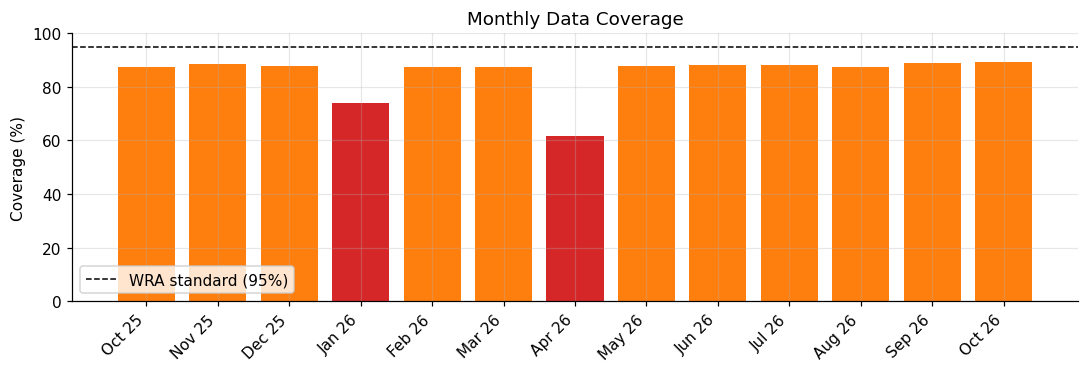

In [6]:
# run_qc: เอาไว้กรองค่าผิดปกติของเซนเซอร์ + คำนวณ TI
clean = qc.run_qc(raw)
display(qc.coverage_report(clean)) # coverage % รายเซนเซอร์ + ผ่านหรือไม่ผ่านเกณฑ์ 95%

gap = qc.gap_structure(clean['WS100'], SITE['records_per_day'])
print(f"ช่องว่างข้อมูลที่ยาวที่สุด : {gap['longest_gap_hours']:.1f} ชม. , ({gap['longest_gap_hours'] / 24:.1f} วัน)")
print(f"ข้อมูลที่ขาดเกิน 1 วัน  : {gap['gaps_over_1day']} ครั้ง") # ยิ่งเยอะ = logger จะดับเป็นก้อนใหญ่

# กราฟ
monthly = clean['WS100'].notna().resample('MS').mean() * 100
fig, ax = plt.subplots(figsize = (10, 3.5))
colors = ['#d62728' if v < 80 else '#ff7f0e' if v < 95 else '#2ca02c' for v in monthly]
ax.bar(range(len(monthly)), monthly.values, color = colors)
ax.axhline(95, color = 'k', ls = '--', lw = 1, label = 'WRA standard (95%)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels([d.strftime('%b %y') for d in monthly.index], rotation = 45, ha = 'right')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0,100)
ax.set_title('Monthly Data Coverage')
ax.legend()
plt.tight_layout()
plt.show()

### 3.1 Turbulence Intensity (TI)

In [7]:
# TI (ความปั่นป่วน) = SD / ความเร็วเฉลี่ย
# IEC ให้ดูที่ช่วง 15 m/s เป็นหลัก
print('TI ค่ามัธยฐานรวม :', round(clean['TI'].median(), 4))
for lo, hi in [(14,16),(10,12),(6,8)]:
    m = (clean['WS160_NW'] >= lo) & (clean['WS160_NW'] < hi)
    if m.sum() > 0:
        print(f" ช่วงข้อมูล {lo}-{hi} m/s : TI = {clean.loc[m, 'TI'].mean():.4f} (จาก {m.sum():,} แถว)")
    else:
        print(f" ช่วง {lo}-{hi} m/s : ไม่มีข้อมูล")

TI ค่ามัธยฐานรวม : 0.1214
 ช่วงข้อมูล 14-16 m/s : TI = 0.1097 (จาก 1,058 แถว)
 ช่วงข้อมูล 10-12 m/s : TI = 0.1146 (จาก 6,197 แถว)
 ช่วงข้อมูล 6-8 m/s : TI = 0.1222 (จาก 11,420 แถว)


### 4.Feature + wind shear (α) + กราฟ Vertical Profile

Win shear (σ) : 0.1999
Row ที่ใช้ได้ : 41,711 จาก 52,560 (79.4%)
Train : 29,197 Row
Test : 12,514 Row


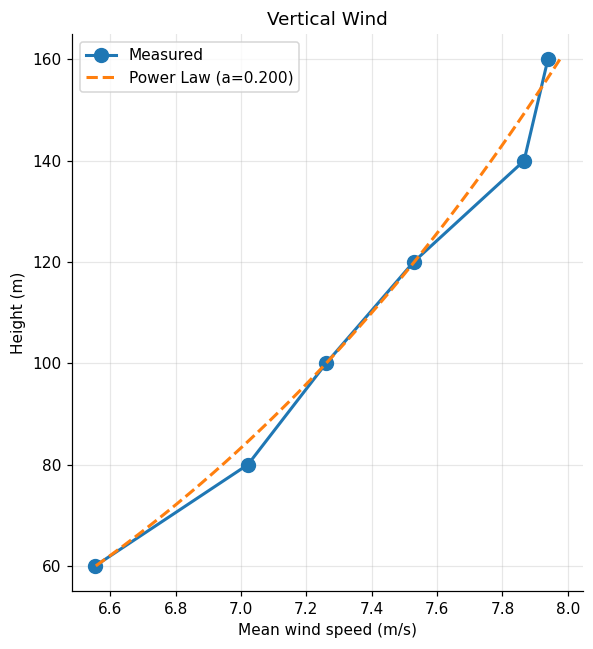

In [8]:
# build_features คือแปลงข้อมูลทิศทางและเวลา เป็นค่า sin-cos + สร้าง shear_low
feat = features.build_features(clean)

# compute_alpha คือการคำนวณค่า Alpha จากข้อมูล และใช้ median
feat, ALPHA = features.compute_alpha(feat)

# splite_by_time แบ่งข้อมูล Train/Test ตามเวลา  
train_data, test_data = features.split_by_time(feat)

num_used = len(train_data) + len(test_data)
print(f"Win shear (σ) : {ALPHA:.4f}")
print(f"Row ที่ใช้ได้ : {num_used:,} จาก {len(feat):,} ({num_used / len(feat) * 100:.1f}%)")
print(f"Train : {len(train_data):,} Row")
print(f"Test : {len(test_data):,} Row")
if num_used / len(feat) < 0.5:
    print('ข้อมูลใช้ได้น้อยกว่าครึ่ง')

# กราฟ Vertical Profile ลมเฉลี่ยและ Power Law
heat_map = {}
for col,h in SITE['sensor_heights'].items():
    if col in clean.columns: heat_map.setdefault(h, []).append(clean[col].mean())

heights = np.array(sorted(heat_map))
mean_wind_speed = np.array([np.mean(heat_map[h]) for h in heights])
fig, ax = plt.subplots(figsize = (5.5, 6))
ax.plot(mean_wind_speed, heights, 'o-', ms = 9, lw = 2, label = 'Measured')

height_level = np.linspace(heights.min(), heights.max(), 50)
ax.plot(mean_wind_speed[heights == 100][0] * (height_level / 100)**ALPHA, height_level, '--', lw = 2, label = f'Power Law (a={ALPHA:.3f})')
ax.set_xlabel('Mean wind speed (m/s)')
ax.set_ylabel('Height (m)')
ax.set_title('Vertical Wind')
ax.legend()
plt.tight_layout()
plt.show()

### 5.เทรนโมเดล และวัดผลลัพธ์ที่ได้

In [9]:
# ลมมที่ยอดเสา
TARGET = f"WS{SITE['mast_height_m']}"

# train_all คือเทรน Power Law (baseline) -> Linear -> Random Forest -> RF ที่ผ่าน Alpha แล้ว
scores, trained = models.train_all(train_data, test_data, features.FEATURE_COLUMNS, TARGET, ALPHA)
display(scores)

,MAE,RMSE,MAPE,R2
model,,,,
LightGBM,0.1282,0.1638,1.7673,0.9955
HistgradientBoosting,0.1288,0.1641,1.7725,0.9955
XGBoost,0.1284,0.1715,1.7707,0.9950
Random Forest pass α,0.1324,0.1813,1.8290,0.9945
Linear Regression,0.1489,0.1914,2.1193,0.9938
Random Forest,0.1469,0.1996,2.0062,0.9933
SVR,0.1673,0.2216,2.2670,0.9917
Power Law (baseline),0.2150,0.2928,2.8494,0.9855


In [10]:
# เช็ค key/label
print('keys ในโมเดล :', list(trained.keys()))
print('labels ในตาราง :', scores.index.tolist())

keys ในโมเดล : ['linear', 'random_forest', 'hist_gb', 'svr', 'xgboost', 'lightgbm', 'random_forest_alpha']
labels ในตาราง : ['LightGBM', 'HistgradientBoosting', 'XGBoost', 'Random Forest pass α', 'Linear Regression', 'Random Forest', 'SVR', 'Power Law (baseline)']


In [11]:
# save Model
models.save_model(
    trained['random_forest_alpha'], 
    'random_forest_alpha', 
    DATA_VERSION, 
    features.FEATURE_COLUMNS, 
    scores.loc['Random Forest pass α'].to_dict())

'random_forest_alpha_GWD_10_160_2026 08 11_ 08 35_11dde3f6'

#### 5.1 กราฟเทียบ RMSE ของทุกโมเดล

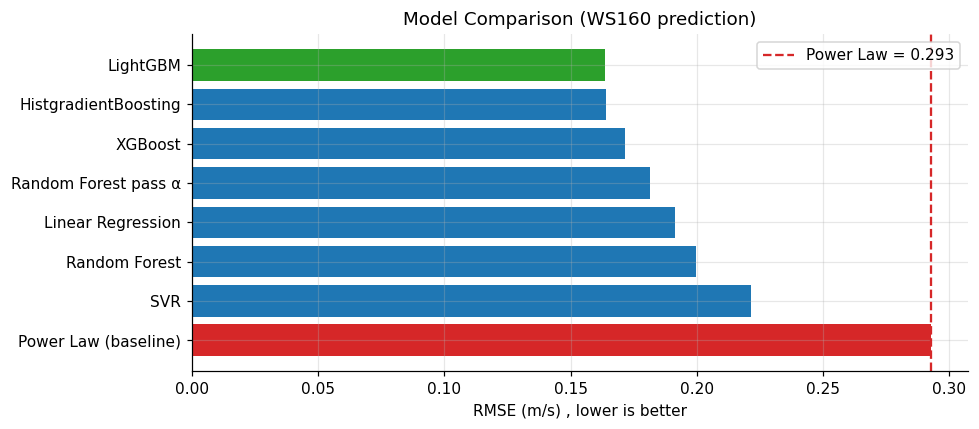

โมเดลที่ดีที่สุด: LightGBM  (RMSE = 0.1638, R2 = 0.9955)


In [12]:
order = scores.sort_values('RMSE', ascending=True)
colors = ['#d62728' if m == 'Power Law (baseline)' else '#2ca02c' if i == 0 else '#1f77b4'
          for i, m in enumerate(order.index)]
fig, ax = plt.subplots(figsize = (9,4))
ax.barh(range(len(order)), order['RMSE'].values, color = colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order.index)
ax.invert_yaxis() # โมเดลที่ดีที่สุดอยู่ข้างบน

base = scores.loc['Power Law (baseline)','RMSE']
ax.axvline(base, color='#d62728', ls = '--', lw = 1.5, label = f'Power Law = {base:.3f}')
ax.set_xlabel('RMSE (m/s) , lower is better'); ax.set_title('Model Comparison (WS160 prediction)')
ax.legend()
plt.tight_layout()
plt.show()

best = order.index[0]
print(f'โมเดลที่ดีที่สุด: {best}  (RMSE = {order.iloc[0]["RMSE"]:.4f}, R2 = {order.iloc[0]["R2"]:.4f})')

### 6.Hub height + MCP + กราฟ MCP

In [13]:
HUB_HEIGHT_M = 150

# ใช้โมเดล Random Forest α ทำนายค่า α ทุกแถว
all_feat = feat[features.FEATURE_COLUMNS].dropna()
wind_hub = pd.Series(all_feat['WS100'].to_numpy() * (HUB_HEIGHT_M / 100)**trained['random_forest_alpha'].predict(all_feat), index = all_feat.index)

# ฟีเจอร์สำหรับทำ MCP
def mcp_features(day):
    day = day.copy()
    day['month_sin'] = np.sin(2 * np.pi * day.index.dayofyear / 365)
    day['month_cos'] = np.cos(2 * np.pi * day.index.dayofyear / 365)
    day['hour_sin'] = np.sin(2 * np.pi * day.index.hour / 24)
    day['hour_cos'] = np.cos(2 * np.pi * day.index.hour / 24)
    return day

MCP_COLS = ['era_ws','month_sin','month_cos','hour_sin','hour_cos']
overlap = mcp_features(era5.join(wind_hub.resample('1h').mean().rename('site'), how = 'inner').dropna())
cut = overlap.index[int(len(overlap) * 0.7)]
mcp = models.make_random_forest(min_samples_leaf = 10).fit( overlap.loc[:cut, MCP_COLS], overlap.loc[:cut,'site'])
mcp_score = models.evaluate(overlap.loc[cut:,'site'], mcp.predict(overlap.loc[cut:, MCP_COLS]), 'MCP')
display(pd.DataFrame([mcp_score]).set_index('model').round(4))

,MAE,RMSE,MAPE,R2
model,,,,
MCP,1.0675,1.337,15.4398,0.7296


In [14]:
# ทำนายลมย้อนหลัง 20 ปี
longterm = mcp_features(era5)
longterm['wind_lt'] = mcp.predict(longterm[MCP_COLS])
annual = longterm['wind_lt'].resample('YS').mean()
IAV = float(annual.std() / annual.mean())
diff = (wind_hub.mean() / longterm['wind_lt'].mean() - 1) * 100
print(f"IAV (ความผันผวนรายปี) : {IAV * 100:.2f}%")
print(f"ปีที่ทำการวัด เปรียบเทียบกับ ค่าระยะยาว : {diff:+.2f}%")
if abs(diff) > 3 * IAV * 100 and mcp_score['R2'] < 0.6:
    print(f"ผลต่าง {diff:+.1f}% สูงกว่าค่า IAV แต่ค่า MCP R2 = {mcp_score['R2']:.2f} ต่ำ")

IAV (ความผันผวนรายปี) : 5.37%
ปีที่ทำการวัด เปรียบเทียบกับ ค่าระยะยาว : +7.97%


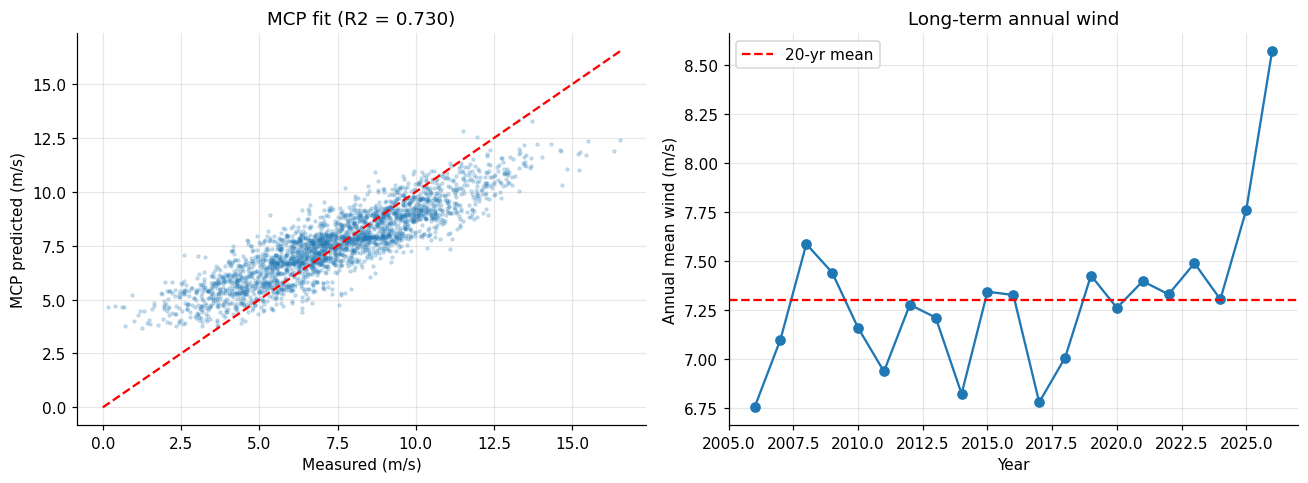

In [15]:
# กราฟ MCP
overview_longterm = overlap.loc[cut:]
fig, ax = plt.subplots(1, 2, figsize = (12, 4.5))
ax[0].scatter(overview_longterm['site'], mcp.predict(overview_longterm[MCP_COLS]), s = 4, alpha = 0.2)
limit = [0, max(overview_longterm['site'].max(), 1)]
ax[0].plot(limit, limit, 'r--')

ax[0].set_xlabel('Measured (m/s)');
ax[0].set_ylabel('MCP predicted (m/s)')
ax[0].set_title(f"MCP fit (R2 = {mcp_score['R2']:.3f})")

ax[1].plot(annual.index.year, annual.values, 'o-')
ax[1].axhline(annual.mean(), color = 'r', ls = '--', label = '20-yr mean')

ax[1].set_xlabel('Year')
ax[1].set_ylabel('Annual mean wind (m/s)')
ax[1].set_title('Long-term annual wind')
ax[1].legend()
plt.tight_layout()
plt.show()

### 7.Weibull -> AEP -> P50/P90 และแสดงกราฟ Weibull และ Exceedance

Weibull k = 3.360, A = 8.111 m/s (mean = 7.282 m/s)
Air density (rho) = 1.1708 kg/m3
Capacity Factor = 23.70%
Total sigma = 10.01%


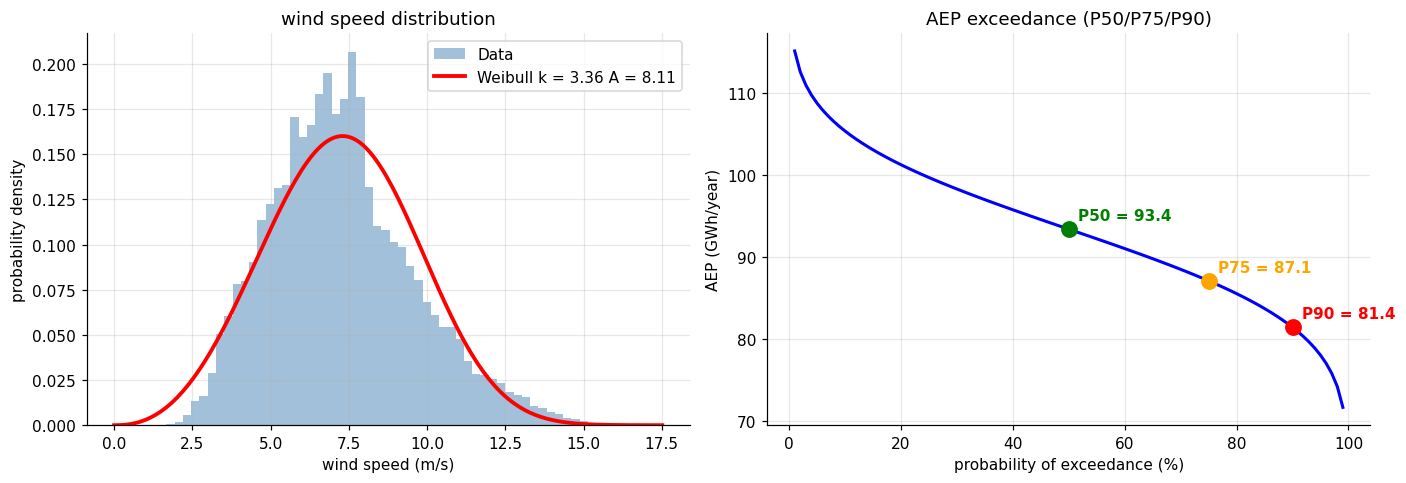

In [16]:
from scipy import stats
# fit Weibull จากค่าลมระยะยาว 20 ปี
k, A = energy.fit_weibull(longterm['wind_lt'])
adc = energy.air_density(clean['Temp'].mean(), clean['Pres'].mean())
aep = energy.calculate_aep(k, A, adc)

UNCERTAINTY = {'measurement':.03, 'vertical':.04, 'mcp':.035, 'power_curve':.05, 'wake':.03, 'iav':IAV} # ค่าจำลอง
p = energy.exceedance_levels(aep['net_farm_gwh'], UNCERTAINTY)

print(f"Weibull k = {k:.3f}, A = {A:.3f} m/s (mean = {energy.weibull_mean(k,A):.3f} m/s)")
print(f"Air density (rho) = {adc:.4f} kg/m3")
print(f"Capacity Factor = {aep['capacity_factor_pct']:.2f}%")
print(f"Total sigma = {p['sigma_total'] * 100:.2f}%")

# กราฟซ้าย Weibull-fit ,กราฟขวา Execcdance P50/P75/P90
fig, ax = plt.subplots(1, 2, figsize = (13, 4.5))
value = longterm['wind_lt'].dropna().to_numpy()
value = value[value > 0]
ax[0].hist(value, bins = 60, density = True, alpha = .5, color = 'steelblue', label = 'Data')

excluding_Short_term = np.linspace(0, value.max(), 200)
ax[0].plot(excluding_Short_term, stats.weibull_min.pdf(excluding_Short_term, k, 0, A), 'r-', lw = 2.5, label = f'Weibull k = {k:.2f} A = {A:.2f}')
ax[0].set_xlabel('wind speed (m/s)')
ax[0].set_ylabel('probability density')
ax[0].set_title('wind speed distribution')
ax[0].legend()

probs = np.linspace(1, 99, 99)
ax[1].plot(probs, p['P50'] * (1 - stats.norm.ppf(probs / 100) * p['sigma_total']), 'b-', lw = 2)
for lab, pr, c in [('P50', 50, 'green'), ('P75', 75, 'orange'), ('P90', 90, 'red')]:
    val = p['P50'] * (1 - stats.norm.ppf(pr / 100) * p['sigma_total'])
    ax[1].plot(pr, val, 'o', color = c, ms = 10)
    ax[1].annotate(f'{lab} = {val:.1f}', (pr, val), textcoords = 'offset points', xytext = (6, 6), color = c, fontweight = 'bold')

ax[1].set_xlabel('probability of exceedance (%)')
ax[1].set_ylabel('AEP (GWh/year)')
ax[1].set_title('AEP exceedance (P50/P75/P90)')
plt.tight_layout()
plt.show()

### 8.ตารางความคุ้มค่าการลงทุน

In [19]:
# อธิบายความหมาย
print('P50/P75/P90 = ระดับค่าความน่าจะเป็น ความเชื่อมั่นในทางสถิติ')
print('NPV = กำไรสุทธิ ค่าบวกถือว่าคุ้มทุน')
print('IRR = ผลตอบแทน %')
print('LCOE = ต้นทุนต่อหน่วย ค่าต่ำถือว่าดี')

capacity_mw = energy.DEFAULT_TURBINE['rated_kw'] * energy.DEFAULT_TURBINE['num_turbines'] / 1000
rows = []
for lab in ['P50', 'P75', 'P90']:
    r = finance.financial_analysis(p[lab], capacity_mw)
    rows.append({
        'Level':lab, 'AEP (GWh)':round(p[lab],2),
        'NPV (MUSD)':round(r['NPV_musd'],2),
        'IRR (%)':round(r['IRR_pct'],2),
        'Break even (year)':r['payback_years'],
        'LCOE (THB/kWh)':round(r['LCOE_thb_per_kwh'],2)
        })
finance_table = pd.DataFrame(rows).set_index('Level')
display(finance_table)

P50/P75/P90 = ระดับค่าความน่าจะเป็น ความเชื่อมั่นในทางสถิติ
NPV = กำไรสุทธิ ค่าบวกถือว่าคุ้มทุน
IRR = ผลตอบแทน %
LCOE = ต้นทุนต่อหน่วย ค่าต่ำถือว่าดี


,AEP (GWh),NPV (MUSD),IRR (%),Break even (year),LCOE (THB/kWh)
Level,,,,,
P50,93.42,-74.73,7.49,11,3.08
P75,87.11,-254.05,6.22,12,3.31
P90,81.44,-415.45,5.03,13,3.54


#### 8.1 บันทึกผลเป็นไฟล์ .csv ลง Folder data/outputs/

In [ ]:
# บันทึกผลเป็น .csv
data_io.save_output(scores, 'model_scores') # ตารางเปรียบเทียบโมเดล
data_io.save_output(finance_table, 'finance_PXX') # ตารางความคุ้มทุน
data_io.save_output(longterm[['wind_lt']], 'longterm_wind') # ลมระยะยาว 20 ปี

summary = pd.DataFrame([{
    'site': SITE['station_code'],
    'data_version': DATA_VERSION,
    'alpha': round(ALPHA,4),
    'weibull_k': round(k,3),
    'weibull_A': round(A,3),
    'capacity_factor_pct': round(aep['capacity_factor_pct'],2),
    'P50_GWh': round(p['P50'],2),
    'P90_GWh': round(p['P90'],2),
    'NPV_P90_MTHB': round(finance.financial_analysis(p['P90'], capacity_mw)['NPV_mthb'],1),
}])
data_io.save_output(summary, 'site_summary')
display(summary)

Save: /home/jovyan/project/data/outputs/model_scores_2026 08 11_ 08 38.csv
Save: /home/jovyan/project/data/outputs/finance_PXX_2026 08 11_ 08 38.csv
Save: /home/jovyan/project/data/outputs/longterm_wind_2026 08 11_ 08 38.csv
Save: /home/jovyan/project/data/outputs/site_summary_2026 08 11_ 08 38.csv


,site,data_version,alpha,weibull_k,weibull_A,capacity_factor_pct,P50_GWh,P90_GWh,NPV_P90_MTHB
0,GWD_10_160,GWD_10_160_2026 08 11_ 08 35_11dde3f6,0.1999,3.36,8.111,23.7,93.42,81.44,-415.4


### 9.สรุปผลที่ได้

In [21]:
from datetime import datetime
res90 = finance.financial_analysis(p['P90'], capacity_mw)

print(f"ไซต์งาน: {SITE['station_code']}  จังหวัด: {SITE['province']}  ({SITE['latitude']}, {SITE['longitude']})")
print('')
print(f"ช่วงข้อมูล : {raw.index.min():%d %b %Y} - {raw.index.max():%d %b %Y}")
print(f"Data version : {DATA_VERSION}")
print(f"รายงาน : {datetime.now():%d %b %Y %H:%M}")
print('')
print(f"Alpha (α) = {ALPHA:.4f}")
print(f"Weibull k = {k:.3f}, A = {A:.3f}")
print(f"Capacity Factor = {aep['capacity_factor_pct']:.2f}%")
print(f"P50 = {p['P50']:.2f} GWh/ปี")
print(f"P75 = {p['P75']:.2f} GWh/ปี")
print(f"P90 = {p['P90']:.2f} GWh/ปี")
print(f"ข้อสรุป (P90): {'คุ้มค่า' if res90['NPV_musd'] > 0 else 'ยังไม่คุ้มค่า'}")
print(f"NPV = {res90['NPV_musd']:.2f} ล้านบาท")
print(f"IRR = {res90['IRR_pct']:.2f}%")

ไซต์งาน: GWD_10_160  จังหวัด: county_name  (15.98565, 104.2271899)

ช่วงข้อมูล : 08 Oct 2025 - 07 Oct 2026
Data version : GWD_10_160_2026 08 11_ 08 35_11dde3f6
รายงาน : 11 Aug 2026 08:38

Alpha (α) = 0.1999
Weibull k = 3.360, A = 8.111
Capacity Factor = 23.70%
P50 = 93.42 GWh/ปี
P75 = 87.11 GWh/ปี
P90 = 81.44 GWh/ปี
ข้อสรุป (P90): ยังไม่คุ้มค่า
NPV = -415.45 ล้านบาท
IRR = 5.03%
